# 1 Solving a model

It is relatively easy to get going with a quick simulation in MuFFiN. The following code solves the multiscale formulation of flow through a four-regular network in a few lines.

The first step is to import the necessary subpackages from the parent package.

In [1]:
import muffin.parameters.parameters as parameters 
import muffin.cells.cells as cells
import muffin.equations_preprocess.equations_preprocess as equations_preprocess
import muffin.equations_flow.equations_flow as equations_flow
import muffin.models.models as models


To begin the example simulation, we first set the parameters. For simplicity, we use the default parameters in this simulation. Further discussion of the parameters and how to select them can be found in another example.

In [2]:
dist_cond = {"name":"delta", "mu":1.0}

my_parameters = parameters.Parameters(time_max = 10, 
                                      dist_cond=dist_cond)

Next, we choose the periodic cell from which the microscale network is composed. For simplicity, we use a four-regular cell (i.e., a cubic lattice) in this example. Further discussion of cells and how to select them can be found in another example.

In [3]:
my_cell = cells.FourRegular(parameters=my_parameters)

We now define the equations to solve. There are two sets of equations: the preprocess equations, and the flow equations. Firstly, we define the preprocess equations. This is a system of algebraic differential equations to solve the microscale cell problem and find the permeability and adhesivity as a function of a timelike variable. For more information, see 'Multiscale models explained' (TODO: link).

In [4]:
my_equations_preprocess = equations_preprocess.Deposition(parameters=my_parameters)

Secondly, we define the flow equations. This is a system of differential equations to solve the macroscale problem and find concentration and flow rate by calculating the timelike variable and interpolating the permeability and adhesivity found in the preprocessing step. For more information, see 'Multiscale models explained' (TODO: link).

In [5]:
my_equations_flow = equations_flow.Base(parameters=my_parameters)

Next, we load the parameters, the cell, and the equations into the model. Note that we set the parameter 'show_on' to True so that later plots are displayed in the notebook (as opposed to saved at a specified path).

In [6]:
my_model = models.Model(parameters=my_parameters, 
                        cell=my_cell, 
                        equations_preprocess=my_equations_preprocess, 
                        equations_flow=my_equations_flow, 
                        show_on=True)

We then solve the model.

In [7]:
my_model.solve(type_solve="all")

Once we have found the solution, we visualise it using the plot method.

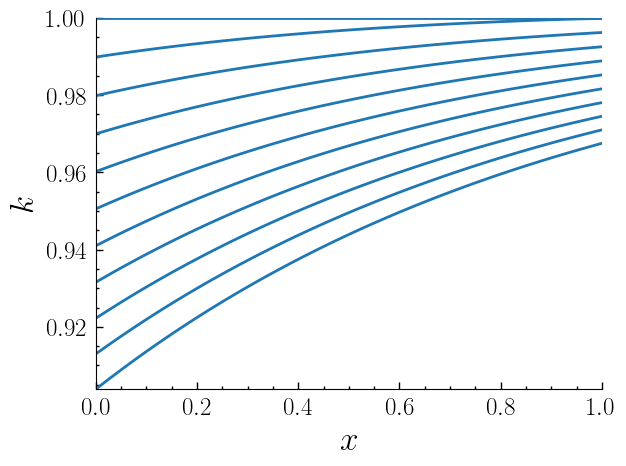

In [8]:
my_model.plot(type_solution="flow", 
           type_plot="single", 
           y_name="permeability")

We can also save the model

In [9]:
my_model.save(type_save="all")

We also have control over parameters.

In [10]:

dist_cond = {"name":"lognormal", "mu":-0.045, "sigma":0.3}

other_parameters = parameters.Parameters(time_max = 10, 
                                         dist_cond = dist_cond)

other_cell = cells.FourRegular(parameters=other_parameters)
other_equations_preprocess = equations_preprocess.Deposition(parameters=other_parameters)
other_equations_flow = equations_flow.Base(parameters=other_parameters)



We load a new model in the same way as before.

In [11]:
other_model = models.Model(parameters=other_parameters, 
                           cell=other_cell, 
                           equations_preprocess=other_equations_preprocess, 
                           equations_flow=other_equations_flow, 
                           show_on=True)

We can then solve the new model with these new parameters.

In [12]:
other_model.solve()

We can then plot the solution, and, for example, compare it to the other model.

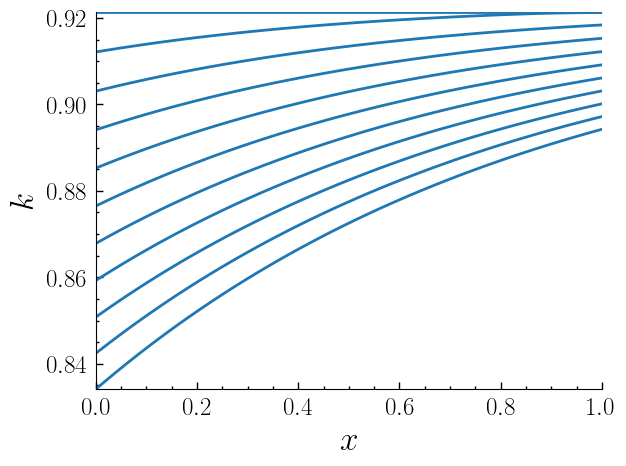

In [13]:
other_model.plot(type_solution="flow", 
                 type_plot="single", 
                 y_name="permeability")